**Créditos**: El contenido de este cuaderno ha sido tomado de varias fuentes, como: [Mauricio Cordeiro](https://cordmaur.medium.com/), [Dorothy Rono](https://medium.com/euro-data-cube/harness-the-power-of-sentinel-hub-xcube-eoxhub-geodb-and-more-in-euro-data-cube-31c827a3083b), pero especialmente de los cursos y libros publicados abierta y libremente por [Dani Arribas-Bel](http://darribas.org/) - Universidad de Liverpool & - Sergio Rey - [Centro de Ciencias Geoespaciales, Universidad de California, Riverside](http://spatial.ucr.edu/peopleRey.html). El compilador se disculpa por cualquier omisión involuntaria y estaría encantado de agregar un reconocimiento.


## Datos espaciales

Los datos espaciales son **datos referenciados geográficamente**, proporcionados en ubicaciones conocidas y a menudo representados visualmente a través de mapas. Esa referencia geográfica, o el componente de ubicación de los datos, puede representarse utilizando cualquier sistema de referencia de coordenadas, por ejemplo, geográfica o proyectada.

Los datos geoespaciales son datos sobre objetos, eventos o fenómenos que tienen una ubicación en la superficie de la tierra, incluyendo información de ubicación, información de atributos (las características del objeto, evento o fenómeno en cuestión) y, a menudo, también información temporal (el tiempo o la duración en que la ubicación y los atributos existen).

Los datos geográficos tienen dos características muy útiles su ubicación y la relacion con sus vecinos. Todo tiene una **ubicación** en el espacio-tiempo, y esta ubicación puede usarse directamente para hacer mejores predicciones o inferencias. Además, esta ubicación te permite comprender las **relaciones** entre las observaciones. A menudo son las relaciones las que son útiles en la ciencia de datos porque nos permiten contextualizar nuestro análisis, creando vínculos dentro de nuestros datos existentes y más allá con otros datos relevantes. Como argumentó el geógrafo Waldo Tobler, las cosas cercanas tienden a estar más relacionadas que las cosas distantes, tanto en el espacio como en el tiempo. Por lo tanto, si aprendemos de los alrededores de manera adecuada, es posible que podamos construir mejores modelos. Un **patrón espacial** observado puede deberse estrictamente a variables **dependientes de la ubicación**, o debido a **interacciones directas** entre las observaciones.

En otras palabras, **los datos espaciales son dependientes o correlacionados espacialmente**, y la independencia entre las observaciones, que es una suposición común en muchas técnicas estadísticas, no se cumple. Existe una diferencia fundamental entre la estadística clásica y la estadística espacial. En la estadística clásica, hacemos una suposición básica sobre la muestra: es una colección de **observaciones independientes** que siguen una distribución específica, generalmente normal. Por el contrario, en la estadística espacial, debido a la inherente **dependencia espacial** y al hecho de que generalmente existe **autocorrelación espacial**, el enfoque se centra en adoptar técnicas para detectar y describir estas correlaciones. En otras palabras, en la estadística clásica, debe existir independencia entre las observaciones, mientras que en la estadística espacial, generalmente existe dependencia espacial.

Al igual que un modelo estadístico, un *mapa* es solo una representación del proceso geográfico subyacente. En este sentido, utilizaremos el término **modelo de datos** para referirnos a cómo representamos conceptualmente un proceso geográfico; y usaremos **estructura de datos** para referirnos a cómo se representan los datos geográficos en una computadora. 

## Modelo de datos
La representación conceptual de un proceso geográfico a menudo no es fácil de representar. Por ejemplo, los mapas de densidad de población generalmente requieren que contemos el número de personas que viven dentro de una "área de enumeración" específica, y luego dividimos por el área total. Esto representa la densidad del área como un valor constante en toda la unidad de enumeración. Pero, las personas son discretas: cada uno de nosotros existe solo en un punto específico en el espacio y el tiempo. Entonces, a una escala de medición suficientemente detallada (tanto en tiempo como en espacio), la densidad es cero en la mayoría de los lugares y momentos. Además, en el día típico de una persona, puede moverse del trabajo a casa, posiblemente pasando por algunos puntos en el espacio-tiempo en el proceso. Por ejemplo, la mayoría de los centros comerciales tienen *cero* residentes, pero su densidad de población es muy alta en un momento específico, y atrae a su población de otros lugares.

Este ejemplo de densidad de población ayuda a ilustrar los modelos clásicos de datos en la ciencia de la información geográfica. Los procesos geográficos se representan generalmente utilizando *objetos*, *campos* y *redes*.
- **Objetos** son *entidades discretas* que ocupan una posición específica en el espacio y el tiempo.
- **Campos** son *superficies continuas* que, en teoría, podrían medirse en cualquier ubicación en el espacio y el tiempo.
- **Redes** reflejan un conjunto de *conexiones* entre *objetos* o entre posiciones en un *campo*.

En nuestro ejemplo de densidad de población, una "unidad de enumeración" es un objeto, al igual que una persona. La representación en campos conceptualizaría la densidad simplemente como una superficie suave y continua que refleja el número total de personas en cada ubicación posible. La representación de la red representaría el sistema interrelacionado de densidades que surgen de las personas que se desplazan.

## Estructura de datos
Las estructuras de datos son representaciones computacionales que organizan diferentes tipos de datos en alineación tanto con el modelo que representan como con el propósito que dichos datos cumplen. Forman la capa intermedia que conecta los modelos conceptuales con la tecnología. En el mejor de los casos, acomodan los principios del modelo de datos de la mejor manera posible desde el punto de vista tecnológico. Al hacerlo, las estructuras de datos permiten que los modelos de datos guíen la computación.

<center><img src="https://www.researchgate.net/profile/Alice-Zwerling/publication/30001990/figure/fig2/AS:651893785243661@1532434998703/Schematic-of-possible-attribute-layers-in-a-Geographic-Information-System-GIS-44.png" width="500"></center>

Este es un mundo en evolución que está cambiando rápidamente y redefiniendo cómo traducimos los modelos conceptuales en estructuras computacionales para almacenar datos. Sin embargo, hay algunos estándares clave que han existido durante mucho tiempo y han demostrado su utilidad. En particular: **(i) objetos, (ii) superficies y (iii) gráficos espaciales**. En este libro se tratarán la dos primeras estructuras.

### Objetos
Los objetos almacenan información sobre **tablas geográficas** discretas. Las tablas son estructuras bidimensionales compuestas por filas y columnas; cada fila representa un objeto independiente, mientras que cada columna almacena un atributo de esos objetos. Las tablas geográficas son tablas estándar donde una columna en específico almacena información geográfica. La estructura tabular encaja bien con el modelo de objetos porque divide claramente el espacio en entidades discretas y asigna una geometría a cada entidad según su naturaleza espacial. Más importante aún, las tablas geográficas permiten combinar sin problemas información geográfica y no geográfica. Es casi como si la Geografía fuera simplemente "un atributo más" cuando se trata de almacenamiento y representación en computadora. Esto es poderoso porque existe un amplio soporte en el mundo de las bases de datos para formatos tabulares. Las tablas geográficas integran datos espaciales en este mundo no espacial y le permiten aprovechar gran parte de su poder. Hablando técnicamente, las tablas geográficas están ampliamente respaldadas en una variedad de plataformas. Ejemplos populares incluyen: tablas PostGIS (como una extensión geográfica de PostgreSQL), los marcos de datos `sf` de R o los objetos `GeoDataFrame` de Python, proporcionados por `geopandas`. Aunque cada uno tiene sus particularidades, todos representan implementaciones de un modelo de objetos.

Algunos formatos de archivos que almacenan objetos son:

* Shapefile [.shp, .shx, .dbf, (.prj, .sbn, .sbx, .xml)] --> geodatabase (.gdb)
* Geopackage (.gpkg)
* .Json
* .GeoJSON
* .KML
* .GML
* .SVG
* .DWG

<center><img src="https://pvsmt99345.i.lithium.com/t5/image/serverpage/image-id/49570i26EF3FAEACD21BD4/image-size/medium?v=1.0&px=400" width="500"></center>

```Note
Antes de continuar, es útil mencionar una aclaración rápida sobre la terminología. A lo largo de este curso, independientemente de la estructura de datos utilizada, nos referiremos a una medición sobre una observación como una *característica* (feature). Esto es consistente con otros trabajos en ciencia de datos y aprendizaje automático. Luego, un conjunto de mediciones es una *muestra*. Para las tablas, esto significa que una característica es una columna y una muestra es una fila. Sin embargo, históricamente, los científicos de información geográfica han utilizado la palabra "característica (feature)" para referirse a una observación individual, ya que una "característica" en cartografía es una entidad en un mapa, y "atributo" para describir las características de esa observación. En otros lugares, una *característica* puede llamarse *variable*, y una *muestra* referirse como un registro. Por lo tanto, la terminología coherente es importante: para este curso, una *característica* es un rasgo medido relacionado con una observación (una columna), y una *muestra* es un conjunto de mediciones (una fila).
```

Adicional a los bien conocidos formatos *shp, gpkg adn kml o kmz*, es bastante utilizados los JSON y GeoJSON para archivos espaciales. [JSON](https://www.json.org/json-es.html) (JavaScript Object Notation) es un formato ligero de intercambio de datos. Es fácil de leer y escribir para los humanos. Es fácil de interpretar y generar para las máquinas. Está basado en un subconjunto del Estándar del Lenguaje de Programación JavaScript ECMA-262 3ra Edición - Diciembre de 1999. JSON es un formato de texto completamente independiente del lenguaje, pero utiliza convenciones que son familiares para los programadores de lenguajes de la familia C, incluidos C, C++, C#, Java, JavaScript, Perl, Python y muchos otros. Estas propiedades hacen que JSON sea un lenguaje ideal para el intercambio de datos.

JSON se basa en dos estructuras:

* Una colección de pares nombre/valor. En varios lenguajes, esto se realiza como un objeto, registro, struct, diccionario, tabla hash, lista con clave o array asociativo.
* Una lista ordenada de valores. En la mayoría de los lenguajes, esto se realiza como un array, vector, lista o secuencia.

[GeoJSON](https://es.wikipedia.org/wiki/GeoJSON) es un formato de texto plano para representar geometrías vectoriales, con o sin atributos no espaciales, basado en el JavaScript Object Notation, JSON. GeoJSON admite los siguientes tipos de geometrías: Punto, LineString, Polígono, MultiPoint, MultiLineString, MultiPolygon y GeometryCollection. Los objetos geométricos con propiedades adicionales son objetos Feature. Los conjuntos de características están contenidos en objetos FeatureCollection. Una desventaja de GeoJSON es que su tamaño de archivo puede ser relativamente grande en comparación con otros formatos de capas vectoriales espaciales, como los formatos Shapefile o GeoPackage.

<img src="https://web-mapping.surge.sh/images/simple_feature_types.png" width="500">

En las dos siguientes páginas web se puede explorar un poco mas estos formatos. [http://geojson.io/#map=2/20.0/0.0](http://geojson.io/#map=2/20.0/0.0) y [Mapshaper](https://mapshaper.org/).

A continuación se presenta un ejemplo de la lectura de un archivo espacial tipo *GeoJSON* en Python como una tabla geográfica en formato *GeoDataFrame*. los archivos *shp, gpkg* y demas, se importan de forma similar.

In [ ]:
berlin = gpd.read_file("https://raw.githubusercontent.com/ljwolf/geopython/master/data/berlin-neighbourhoods.geojson") #tambien se puede descargar de "https://raw.githubusercontent.com/ljwolf/geopython/master/data/berlin-neighbourhoods.geojson")

type(berlin)

In [ ]:
berlin.head()

In [ ]:
berlin.crs

In [ ]:
berlin.plot()

#### Datos ordenados (*tidy*) y desordenados (*untidy*)

A menudo se dice que el 80% del análisis de datos se dedica al proceso de limpiar y preparar los datos. Una vez que puedes leer tus datos, explorar casos específicos y tener un primer enfoque visual del conjunto completo, el siguiente paso puede ser prepararlos para un análisis más sofisticado. Tal vez estés pensando en modelarlos a través de una regresión, o en crear subgrupos en el conjunto de datos con características particulares, o simplemente necesitas presentar medidas resumidas que se relacionen con una disposición ligeramente diferente de los datos de la que te han presentado.

Para todos estos casos, primero necesitas lo que el estadístico y experto en R, Hadley Wickham, llama **tidy data (datos ordenados)**. La idea general para "ordenar" tus datos es convertirlos de la estructura en la que te los entregaron a una que permita una manipulación conveniente y estandarizada, y que sea compatible con la entrada directa de datos en lo que él llama herramientas de análisis "*ordenadas*". Pero, a un nivel más práctico, ¿qué son exactamente los *"datos ordenados"*? En palabras del propio Wickham:

> *Los datos ordenados son una forma estándar de mapear el significado de un conjunto de datos a su estructura. Un conjunto de datos está desordenado u ordenado dependiendo de cómo las filas, columnas y tablas se correspondan con observaciones, variables y tipos.*

Los conjuntos de datos ordenados y las herramientas ordenadas trabajan en conjunto para facilitar el análisis de datos, permitiéndote centrarte en el problema interesante del dominio y no en la logística poco interesante de los datos.

Luego, las tres características fundamentales de los "datos ordenados" son:

1. Cada variable forma una columna.
2. Cada observación forma una fila.
3. Cada tipo de unidad de observación forma una tabla.

![Tidy Data](https://images.squarespace-cdn.com/content/v1/5b872f96aa49a1a1da364999/1572008171822-KJ0300DR4KCHW8NUUN1N/ke17ZwdGBToddI8pDm48kP0H4u0KUkchoILChBGMIUUUqsxRUqqbr1mOJYKfIPR7LoDQ9mXPOjoJoqy81S2I8N_N4V1vUb5AoIIIbLZhVYy7Mythp_T-mtop-vrsUOmeInPi9iDjx9w8K4ZfjXt2dskF1CFdD1ghxEpYxbqRasKlXJQr8mv4xxZBDj9ez2c1CjLISwBs8eEdxAxTptZAUg/image.png?format=1500w)

Si te interesa más el concepto de *"datos ordenados"*, te recomiendo que consultes el [artículo original](http://www.jstatsoft.org/v59/i10/) (acceso libre) y el [repositorio público](https://github.com/hadley/tidy-data) asociado a él.

![Tidy Tools](https://images.squarespace-cdn.com/content/v1/5b872f96aa49a1a1da364999/1572032408033-E3XJOTD0M1DINAU5G54Z/ke17ZwdGBToddI8pDm48kNvT88LknE-K9M4pGNO0Iqd7gQa3H78H3Y0txjaiv_0fDoOvxcdMmMKkDsyUqMSsMWxHk725yiiHCCLfrh8O1z5QPOohDIaIeljMHgDF5CVlOqpeNLcJ80NK65_fV7S1USOFn4xF8vTWDNAUBm5ducQhX-V3oVjSmr829Rco4W2Uo49ZdOtO_QXox0_W7i2zEA/tidy.jpg?format=1500w)

#### [Series, DataFrames y GeoDataFrames en Python](https://pandas.pydata.org/pandas-docs/stable/user_guide/dsintro.html)

Aunque cada una de las bases de datos presenta códigos que relacionan los datos con su localización, esto no significa que se entiendan como datos espaciales; al menos para ser trabajados con la mayoría de programas espaciales. Como se puede observar, corresponden a estructuras tipo DataFrames en Python. Para transformar estas bases de datos a información espacial, denominada GeoDataFrames en Python, se requiere una transformación.

Las **Series** es un arreglo unidimensional etiquetado capaz de contener cualquier tipo de dato (enteros, cadenas, números de punto flotante, objetos de Python, etc.). Las etiquetas de los ejes se denominan colectivamente como el índice. **DataFrames** es una estructura de datos etiquetada bidimensional con columnas que pueden tener diferentes tipos. Puedes pensarlo como una hoja de cálculo o una tabla SQL, o un diccionario de objetos Series. Generalmente es el objeto más utilizado de pandas.

<center><img src="https://www.w3resource.com/w3r_images/pandas-data-structure.svg" width="1000"></center>

Un **GeoDataFrame** contiene un conjunto de datos tabulares y geoespaciales:

* Tiene una **columna 'geometry'** que contiene la información de geometría (o características en GeoJSON).
* Las otras columnas son los **atributos** (o propiedades en GeoJSON) que describen cada una de las geometrías.

Un `GeoDataFrame` es similar a un `DataFrame` de pandas, pero con funcionalidad adicional para trabajar con datos geoespaciales:

* Un atributo `.geometry` que siempre devuelve la columna con la información de geometría (devolviendo una GeoSeries). El nombre de la columna no necesariamente tiene que ser 'geometry', pero siempre será accesible como el atributo `.geometry`.
* Tiene algunos métodos adicionales para trabajar con datos espaciales (área, distancia, buffer, intersección, ...), que veremos en los cuadernos posteriores.

Los puntos son el tipo de característica más simple, ya que no tienen ninguna dimensión, solo un par de coordenadas asociadas a ellos. Es posible entocnes construir un GeoDataFrame de puntos de la siguiente manera:

In [ ]:
#importar las librerias necesarias
import geopandas as gpd
from shapely.geometry import Point

#funcion en Python para crear un geodataframe
gdf=gpd.GeoDataFrame({
    'geometry': [Point(1, 1), Point(2, 2)],
    'attribute1': [1, 2],
    'attribute2': [0.1, 0.2]})

type(gdf)

Algunas funciones interesantes que tienen los *GeoDataFrame*, heredadas de los *DataFrames* son:

In [ ]:
gdf.head(2)

In [ ]:
gdf.info()

In [ ]:
gdf.plot()

Es posible también crear un *GeoDataFrame* a partir de un *DataFrame*.

In [ ]:
import pandas as pd


df = pd.DataFrame(
    {'City': ['Buenos Aires', 'Brasilia', 'Santiago', 'Bogota', 'Caracas'],
     'Country': ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Venezuela'],
     'Latitude': [-34.58, -15.78, -33.45, 4.60, 10.48],
     'Longitude': [-58.66, -47.91, -70.66, -74.08, -66.86]})
df

In [ ]:
df['Coordinates']  = list(zip(df['Longitude'], df.Latitude))

df

In [ ]:
df['Coordinates'] = df['Coordinates'].apply(Point)

df

In [ ]:
gdf = gpd.GeoDataFrame(df, geometry='Coordinates')

gdf

SIn embargo en ambos ejemplos aunque tenemos coordenadas y podemos incluso generar un mapa con los puntos, si consultamos el sistema de coordenadas de referencia (*crs*) vamos a obtener que no hemos asignado el sistema.

In [ ]:
print(gdf.crs)

Vamos a ver un ejemplo donde asignemos el *crs*. Los puntos pueden almacenarse en una tabla no geográfica, simplemente usando una columna para cada coordenada. Los datos se almacenan como una tabla de valores separados por comas (*.csv*). En este caso utilizamos geopandas `points_from_xy()` para transformar Longitud y Latitud en una lista de objetos `shapely.Point` y configurarlos como la geometría al crear el GeoDataFrame. Lo que nos interesa son las columnas de latitud y longitud del conjunto de datos.

In [ ]:
import pandas as pd

df = pd.read_csv("https://geographicdata.science/book/_downloads/7fb86b605af15b3c9cbd9bfcbead23e9/tokyo_clean.csv")

type(df)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
geo = gpd.points_from_xy(x=df["longitude"],y=df["latitude"], crs="EPSG:4326")

In [ ]:
gdf = gpd.GeoDataFrame(df, geometry=geo)

In [ ]:
print(gdf.crs)

Para crear *GepDataFrames* para otros objetos como lineas o poligonos es un poco mas complejo el proceso, por lo cual generalmente se importan desde formatos espaciales como *shp* o *gpkg*. Sin embargo veamos un sensillo ejemplo.

In [ ]:
# Crear un GeoDataFrame vacío de geopandas
gdf = gpd.GeoDataFrame()

# Crear una nueva columna llamada 'geometry' en el GeoDataFrame
gdf['geometry'] = None

# Coordenadas de la Plaza del Senado de Helsinki en Grados Decimales
coordenadas = [(24.950899, 60.169158), (24.953492, 60.169158), (24.953510, 60.170104), (24.950958, 60.169990)]

# Crear un polígono de Shapely a partir de la lista de tuplas de coordenadas
poly = Polygon(coordenadas)

# Veamos lo que tenemos
poly

In [ ]:
# Insertar el polígono en la columna 'geometry' en el índice 0
gdf.loc[0, 'geometry'] = poly

# Veamos lo que tenemos ahora
gdf

In [ ]:
# Agregar una nueva columna e insertar datos
gdf.loc[0, 'Location'] = 'Senaatintori'

# Revisemos los datos
gdf

In [ ]:
print(gdf.crs)

In [ ]:
from fiona.crs import from_epsg

gdf.crs = from_epsg(4326)

gdf.crs

In [ ]:
gdf.plot()

### Superficies
Las **Superficies** registran mediciones empíricas de **campos**. Los campos son una representación continua del espacio. En principio, hay un conjunto infinito de ubicaciones para las cuales un campo tiene un valor diferente. En la práctica, los campos se miden en un conjunto discreto de ubicaciones. Este objetivo de continuidad en el espacio (y potencialmente en el tiempo) es importante porque se vincula directamente con la forma en que se estructuran los datos. En la práctica, los campos se registran y almacenan en cuadrículas uniformes o matrices cuyas dimensiones están estrechamente relacionadas con la extensión geográfica del área que representan. Las matrices son estructuras bidimensionales, al menos. A diferencia de las tablas geográficas, las matrices de superficies utilizan tanto filas como columnas para significar la ubicación, y los valores de las celdas almacenan información sobre esa ubicación. Una superficie para un fenómeno dado (por ejemplo, la contaminación del aire) se representará como una matriz en la que cada fila estará vinculada a diferentes latitudes y cada columna representará longitudes. Si queremos representar más de un fenómeno (por ejemplo, contaminación del aire y elevación) o el mismo fenómeno en diferentes puntos del tiempo, necesitaremos diferentes matrices, posiblemente conectadas. Estas matrices multidimensionales a veces se denominan **cubos de datos**.

Los siguientes son probablemente los formatos mas conocidos para información de superficies, y que se denominan archivos tipo raster.

* .img (imagine) --> ERDAS
* GeoTiff (.tif)
* ASCCI (.asc)
* .netCDF

<center><img src="https://pvsmt99345.i.lithium.com/t5/image/serverpage/image-id/49571iD5C49038B1B61684/image-size/medium?v=1.0&px=400" width="500"></center>

<center><img src="https://desktop.arcgis.com/en/arcmap/10.3/manage-data/raster-and-images/GUID-412D5EE2-475A-4AD0-B3BD-2C4DEB1D667E-web.gif" width="800"></center>

Un **cubo de datos** es una matriz de datos multidimensional. En el dominio de los sensores remotos, un cubo de datos sirve imágenes satelitales como una matriz multidimensional, generalmente con dos dimensiones espaciales, una dimensión temporal y un número arbitrario de atributos como bandas o índices. La georreferenciación de las imágenes satelitales garantiza que la ubicación del píxel se mantenga coherente entre las diferentes capas del cubo de datos. El objetivo de un cubo de datos es ofrecer a los usuarios datos listos para el análisis, reduciendo así la carga de preprocesamiento y preparación de datos.

<center><img src="https://desktop.arcgis.com/en/arcmap/10.3/tools/space-time-pattern-mining-toolbox/GUID-0FEECE1A-6B54-44B4-AE49-05E7EA849A8B-web.png" width="500"></center>

Para explorar cómo Python representa las superficies, utilizaremos un extracto de la ciudad brasileña de São Paulo de un [conjunto de datos de población global](../data/ghsl/build_ghsl_extract). Este conjunto de datos registra recuentos de población en celdas de las mismas dimensiones que cubren uniformemente la superficie de la Tierra. Nuestro extracto está disponible como un archivo GeoTIF, una variación del formato de imagen TIF que incluye información geográfica. Podemos usar el método `open_rasterio()` del paquete `xarray` para leer el archivo GeoTIF:


In [ ]:
import xarray
import rioxarray
pop = xarray.open_rasterio("https://geographicdata.science/book/_downloads/5263090bd0bdbd7d1635505ff7d36d04/ghsl_sao_paulo.tif")

In [4]:
type(pop)

xarray.core.dataarray.DataArray

`xarray` es un paquete para trabajar con arreglos etiquetados multidimensionales.

In [5]:
pop.coords

Coordinates:
  * band     (band) int64 1
  * y        (y) float64 -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
  * x        (x) float64 -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06

Curiosamente, nuestra superficie tiene *tres* dimensiones: `x`, `y` y `band`. Las dos primeras rastrean la latitud y la longitud que cubre cada celda en nuestra cuadrícula de población. La tercera tiene un solo valor (1) y, en este contexto, no es muy útil. Pero es fácil imaginar contextos en los que una tercera dimensión sería útil. Por ejemplo, una imagen óptica en color puede tener tres bandas: rojo, azul y verde. Sensores más potentes pueden captar bandas adicionales, como el infrarrojo cercano (NIR) o incluso bandas de radio. O una superficie medida a lo largo del tiempo, como los geocubos, tendrá bandas para cada punto en el tiempo en el que se mide el campo. Una superficie geográfica tendrá, por lo tanto, dos dimensiones que registran la ubicación de las celdas (`x` y `y`), y al menos una `band` que registra otras dimensiones relacionadas con nuestros datos.

Un objeto `xarray.DataArray` contiene información adicional sobre los valores almacenados bajo el atributo `attrs`:


In [6]:
pop.attrs

{'transform': (250.0, 0.0, -4482000.0, 0.0, -250.0, -2822000.0),
 'crs': '+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs=True',
 'res': (250.0, 250.0),
 'is_tiled': 0,
 'nodatavals': (-200.0,),
 'scales': (1.0,),
 'offsets': (0.0,),
 'AREA_OR_POINT': 'Area',
 'grid_mapping': 'spatial_ref'}

In [ ]:
pop.shape

(1, 416, 468)

In [ ]:
pop.sel(band=1)

<xarray.DataArray (y: 416, x: 468)>
[194688 values with dtype=float32]
Coordinates:
    band     int64 1
  * y        (y) float64 -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
  * x        (x) float64 -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
Attributes:
    transform:      (250.0, 0.0, -4482000.0, 0.0, -250.0, -2822000.0)
    crs:            +proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +...
    res:            (250.0, 250.0)
    is_tiled:       0
    nodatavals:     (-200.0,)
    scales:         (1.0,)
    offsets:        (0.0,)
    AREA_OR_POINT:  Area
    grid_mapping:   spatial_ref

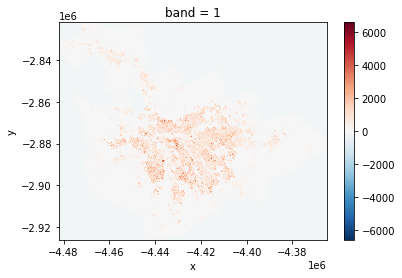

In [7]:
pop.sel(band=1).plot()

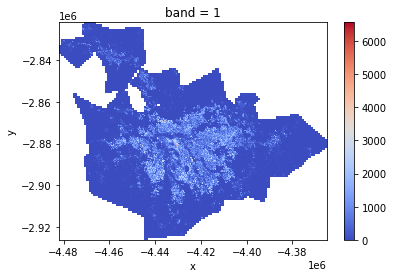

In [9]:
pop.where(pop!=-200).sel(band=1).plot(cmap="coolwarm")

### Redes geográficas}

**Gráficos espaciales** capturan las relaciones entre objetos que están mediadas por el espacio. En cierto sentido, pueden considerarse **redes geográficas**, o una estructura de datos para almacenar topologías. Existen varias formas de definir las relaciones espaciales entre las características. Lo importante a tener en cuenta por ahora es que, independientemente de la regla espacial que sigamos, los gráficos espaciales proporcionan una forma de codificarlas en una estructura de datos que puede admitir análisis. Los gráficos espaciales registran información sobre cómo una observación dada está conectada espacialmente con otras en el conjunto de datos. Por esta razón, son un complemento obvio de las tablas geográficas, que almacenan información sobre observaciones individuales de forma aislada. Los gráficos espaciales también pueden derivarse de superficies, pero aquí la situación es ligeramente diferente porque, aunque las superficies registran mediciones discretas, generalmente se relacionan con un fenómeno continuo. En teoría, uno podría tomar estas mediciones en cualquier punto del espacio, por lo que el gráfico espacial de una superficie debería tener un número infinito de observaciones. En la práctica, sin embargo, los gráficos espaciales *a veces* se utilizan con cuadrículas porque las conexiones y barreras entre modelos y estructuras de datos están desapareciendo muy rápidamente. Dado que muchos campos tienen constructos teóricos que se asemejan a gráficos espaciales, existen varias estructuras de datos ligeramente diferentes que los almacenan tanto en memoria como en disco.

<center><img src="https://d3i71xaburhd42.cloudfront.net/2296001907aa03c91226a66a644b1c047b2a5ae9/11-Figure6-1.png" width="1000"></center>

El término gráfico espacial a veces se utiliza indistintamente con el de **red espacial**. Esto, por supuesto, es una cuestión de convenciones de nomenclatura y, en la medida en que solo es eso, no es muy importante. Sin embargo, la confusión a veces puede reflejar un malentendido más profundo de lo que se está representando. Tomemos el ejemplo de las calles en una ciudad o el sistema interconectado de ríos en un área de captación. Ambos se suelen denominar redes, aunque en muchos casos lo que se registra en realidad es una colección de objetos almacenados en una tabla geográfica. Para aclarar la distinción, debemos pensar en qué aspecto del diseño de la calle o del sistema fluvial queremos registrar. Si es la forma exacta, longitud y ubicación de cada segmento o arroyo, esto se parece mucho más a una colección de líneas o polígonos independientes que "se tocan" en sus extremos. Si lo que nos interesa es entender cómo se *relaciona* cada segmento o río entre sí, qué está conectado con qué y cómo este conjunto de conexiones individuales se convierte en un sistema interconectado más amplio, entonces un gráfico espacial es una estructura más útil para usar. Esta dicotomía entre el objeto y el gráfico es solo un ejemplo de un punto más amplio sobre cómo usamos modelos y estructuras de datos y cómo cuál es el *correcto* no depende solo del fenómeno que estamos tratando de capturar, sino también del porqué queremos representarlo y cuál es el objetivo.

La separación de raster/imagen de vector/tabla y la omisión general de redes provienen de decisiones de implementación realizadas en uno de los primeros sistemas de información geográfica comercialmente exitosos, el paquete ARC/INFO del Instituto de Investigación Ambiental. Este fue un precursor en la línea de comandos de los sistemas modernos de procesamiento de información gráfica, como QGIS gratuito y de código abierto o los paquetes ArcGIS del Instituto de Investigación Ambiental (ESRI). Esta asociación entre campo-y-raster, objeto-y-vector a veces se denomina la "visión de escritorio" de la información geográfica debido al dominio de estos paquetes GIS gráficos.